In [ ]:
import pandas as pd
from datasets import load_dataset

ds = load_dataset("mahmoudalyosify/SCRAP")
df_train = pd.DataFrame(ds['train'])
df_test = pd.DataFrame(ds['test'])

print('Data source import complete.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/399 [00:00<?, ?B/s]

train_data.csv:   0%|          | 0.00/234M [00:00<?, ?B/s]

test_data.csv:   0%|          | 0.00/35.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/162634 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24484 [00:00<?, ? examples/s]

Data source import complete.


# AI-Integrated Satellite Scheduling and Optimization using Linear Programming

In [ ]:
# Install required packages (PuLP usually available on Kaggle; if not:)
!pip install pulp streamlit plotly --quiet
!pip install skyfield

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 25.4 MB/s eta 0:00:00


## Import the libraries

In [ ]:
import os, glob, math, random, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
random.seed(42); np.random.seed(42)
import sys
from sklearn.ensemble import IsolationForest
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpBinary, PULP_CBC_CMD
from skyfield.api import EarthSatellite, load, wgs84
import math, random, glob, os
import numpy as np, pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

## Ensure All the packages

In [ ]:
def pip_install(pkg):
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
required = []
try:
    import pulp
except:
    required.append("pulp")
try:
    from sklearn.ensemble import IsolationForest
except:
    required.append("scikit-learn")
# for precise TLE -> latlon
try:
    import skyfield
    from skyfield.api import EarthSatellite, load, wgs84
except:
    required.append("skyfield")
if required:
    print("Installing:", required)
    for p in required:
        pip_install(p)

In [ ]:
candidates = glob.glob("/kaggle/input/*starlink*")
starlink_dir = None
for c in candidates:
    # small heuristic: dataset that contains tle or csv files
    if os.path.isdir(c):
        csvs = glob.glob(os.path.join(c, "**/*.csv"), recursive=True)
        if csvs:
            starlink_dir = c
            break

if starlink_dir:
    print("Found Starlink dataset directory:", starlink_dir)
else:
    print("No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.")

No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.


## Helper Functions

In [ ]:
def angular_sep(lat1, lon1, lat2, lon2):
    phi1 = math.radians(lat1); phi2 = math.radians(lat2)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin((phi2-phi1)/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    ang = 2*math.degrees(math.asin(min(1, math.sqrt(a))))
    return ang

## Build satellite positions from dataset (or synthetic)

In [ ]:
TIME_SLOTS = 6          # planning horizon (discrete time slots)
SLOT_MINUTES = 10       # minutes between slots (for skyfield time steps)
sat_positions = {}      # mapping (sat_id, slot) -> {'lat', 'lon'}

if starlink_dir:
    # find CSVs with TLE info (or CSVs with lat/lon)
    csv_files = glob.glob(os.path.join(starlink_dir, "**/*.csv"), recursive=True)
    # we will try to find columns: 'line1','line2' or 'tle_line1','tle_line2' or precomputed 'lat','lon'
    tle_rows = []
    precomputed = []
    for csv in csv_files:
        try:
            df = pd.read_csv(csv, low_memory=False)
        except Exception as e:
            continue
        cols = [c.lower() for c in df.columns]
        if any('line1' in c for c in cols) and any('line2' in c for c in cols):
            # normalize names
            # find matching columns
            cline1 = [c for c in df.columns if 'line1' in c.lower()][0]
            cline2 = [c for c in df.columns if 'line2' in c.lower()][0]
            for i,row in df[[cline1,cline2]].iterrows():
                tle_rows.append((str(row[cline1]).strip(), str(row[cline2]).strip()))
        elif any(c in cols for c in ['latitude','lat']) and any(c in cols for c in ['longitude','lon','lng']):
            # precomputed lat/lon dataset
            latcol = [c for c in df.columns if 'lat' in c.lower()][0]
            loncol = [c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()][0]
            for i,row in df.iterrows():
                try:
                    precomputed.append((float(row[latcol]), float(row[loncol])))
                except:
                    continue

    # prefer TLE parsing if present
    if tle_rows:
        print("Using TLE rows from dataset (count {})".format(len(tle_rows)))
        # create EarthSatellite objects (limit to first N for speed)
        N = min(300, len(tle_rows))  # limit number of sats to 300 for speed on Kaggle
        ts = load.timescale()
        # choose a base epoch (now) and build slot times
        t0 = pd.Timestamp.utcnow()
        # create slot times as UTC datetimes
        slot_times = [t0 + pd.Timedelta(minutes=SLOT_MINUTES*i) for i in range(TIME_SLOTS)]
        sky_times = [ts.utc(int(t.year), int(t.month), int(t.day), int(t.hour), int(t.minute), int(t.second)) for t in slot_times]

        # build satellite objects and sample subpoints
        for idx,(l1,l2) in enumerate(tle_rows[:N]):
            satname = f"STAR_{idx:04d}"
            try:
                sat = EarthSatellite(l1, l2, satname)
            except Exception as e:
                # some TLE rows can be malformed; skip
                continue
            for slot_idx, t_ts in enumerate(sky_times):
                geoc = sat.at(t_ts)
                sub = wgs84.subpoint(geoc)
                lat = sub.latitude.degrees
                lon = sub.longitude.degrees
                sat_positions[(satname, slot_idx)] = {'lat': lat, 'lon': lon}
        print("Generated sat_positions for {} satellites x {} slots.".format(N, TIME_SLOTS))
    elif precomputed:
        print("Using precomputed lat/lon entries from dataset.")
        # map entries to pseudo-sats
        N = min(300, len(precomputed))
        for i in range(N):
            satname = f"SAT_{i:04d}"
            lat, lon = precomputed[i]
            for slot in range(TIME_SLOTS):
                # small jitter per slot to simulate motion
                sat_positions[(satname, slot)] = {'lat': lat + 0.01*slot, 'lon': lon + 0.02*slot}
        print("Generated sat_positions from precomputed lat/lon for {} pseudo-sats.".format(N))
    else:
        print("Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.")
        starlink_dir = None  # fallback to synthetic

if not starlink_dir:
    # Synthetic constellation fallback (same safe generator as before)
    NUM_SATS = 80
    sats = []
    for s in range(NUM_SATS):
        raan = random.uniform(0,360); incl = random.uniform(30,85); phase0 = random.uniform(0,360)
        sats.append({'sat_id': f'S{s:03d}', 'raan': raan, 'incl': incl, 'phase0': phase0})
    # sample ground tasks clustered near populated regions
    regions = [(28.6,77.2),(40.7,-74.0),(34.05,-118.24),(51.5,-0.12),(35.68,139.69),(-33.86,151.21)]
    def sample_ground_point():
        base = random.choice(regions)
        return base[0] + random.uniform(-3,3), base[1] + random.uniform(-3,3)
    # compute sat subpoints for each slot using simple orbital approx
    def latlon_from_orbital(raan_deg, incl_deg, phase_deg):
        raan = math.radians(raan_deg); incl = math.radians(incl_deg); phase = math.radians(phase_deg)
        lat = math.degrees(math.asin(math.sin(incl)*math.sin(phase)))
        lon = math.degrees(raan + math.atan2(math.cos(incl)*math.sin(phase), math.cos(phase)))
        lon = ((lon + 180) % 360) - 180
        return lat, lon
    for s in sats:
        for slot in range(TIME_SLOTS):
            phase = (s['phase0'] + slot*40) % 360
            lat, lon = latlon_from_orbital(s['raan'], s['incl'], phase)
            sat_positions[(s['sat_id'], slot)] = {'lat': lat, 'lon': lon}

## Create Tasks

In [ ]:
NUM_TASKS = 40
tasks = []
for t in range(NUM_TASKS):
    # reused region sampling for tasks (realistic clustering)
    regions = [(28.6,77.2),(40.7,-74.0),(34.05,-118.24),(51.5,-0.12),(35.68,139.69),(-33.86,151.21)]
    base = random.choice(regions)
    lat = base[0] + random.uniform(-3,3)
    lon = base[1] + random.uniform(-3,3)
    priority = random.choice([1,2,3,5,8])
    data_mb = random.choice([10,20,40,80])
    tasks.append({'task_id': f'T{t:03d}', 'lat': lat, 'lon': lon, 'priority': priority, 'data_mb': data_mb})
tasks_df = pd.DataFrame(tasks)

## Eligibility (Footprint)

In [ ]:
FOOTPRINT_ANG_DEG = 20.0
eligibility = {}
sat_ids = sorted({k[0] for k in sat_positions.keys()})
for s in sat_ids:
    for slot in range(TIME_SLOTS):
        pos = sat_positions.get((s,slot))
        if pos is None:
            continue
        for _, task in tasks_df.iterrows():
            ang = angular_sep(pos['lat'], pos['lon'], task['lat'], task['lon'])
            eligibility[(s,slot,task['task_id'])] = (ang <= FOOTPRINT_ANG_DEG)

## Simulate Telemetry & AI Anomaly Detection

In [ ]:
telemetry = []
for s in sat_ids:
    level = random.uniform(60,100)
    for slot in range(TIME_SLOTS):
        level += random.uniform(-8,3)
        if random.random() < 0.02:
            level -= random.uniform(20,50)
        level = max(0, min(100, level))
        telemetry.append({'sat_id': s, 'slot': slot, 'battery': level})
tele_df = pd.DataFrame(telemetry)
clf = IsolationForest(contamination=0.02, random_state=42)
clf.fit(tele_df[['battery']])
tele_df['anomaly'] = (clf.predict(tele_df[['battery']]) == -1)
unavailable = set((row['sat_id'], int(row['slot'])) for _, row in tele_df[tele_df['anomaly']].iterrows())

print("Detected anomalies (sat,slot) count:", len(unavailable))

Detected anomalies (sat,slot) count: 10


##  MILP Formulation

In [ ]:
prob = LpProblem('sat_sched', LpMaximize)
x = {}
for s in sat_ids:
    for slot in range(TIME_SLOTS):
        for tid in tasks_df['task_id']:
            if eligibility.get((s,slot,tid), False) and ((s,slot) not in unavailable):
                x[(s,slot,tid)] = LpVariable(f"x_{s}_{slot}_{tid}", cat=LpBinary)

# objective: maximize priority with slight preference to earlier slots
prob += lpSum((int(tasks_df.loc[tasks_df['task_id']==tid,'priority'].values[0]) * (1 - 0.05*slot)) * var
              for (s,slot,tid), var in x.items())

# constraints
# each task at most once
for tid in tasks_df['task_id']:
    prob += lpSum(x[(s,slot,tid)] for (s,slot,t) in x.keys() if t==tid) <= 1
# each sat at most one task per slot
for s in sat_ids:
    for slot in range(TIME_SLOTS):
        prob += lpSum(x[(s,slot,t)] for (ss,sl,t) in x.keys() if ss==s and sl==slot) <= 1
# downlink capacity per slot
DOWNLINK_CAP_MB = 1000
for slot in range(TIME_SLOTS):
    prob += lpSum(tasks_df.loc[tasks_df['task_id']==t,'data_mb'].values[0] * x[(s,slot,t)]
                  for (s,sl,t) in x.keys() if sl==slot) <= DOWNLINK_CAP_MB
# conflict avoidance: if two sats are too close, at most one active in the slot
MIN_SEP_DEG = 2.5
for slot in range(TIME_SLOTS):
    for i in range(len(sat_ids)):
        for j in range(i+1, len(sat_ids)):
            s1 = sat_ids[i]; s2 = sat_ids[j]
            pos1 = sat_positions.get((s1,slot)); pos2 = sat_positions.get((s2,slot))
            if pos1 is None or pos2 is None: continue
            sep = angular_sep(pos1['lat'], pos1['lon'], pos2['lat'], pos2['lon'])
            if sep < MIN_SEP_DEG:
                vars_s1 = [x[(s1,slot,t)] for (ss,sl,t) in x.keys() if ss==s1 and sl==slot]
                vars_s2 = [x[(s2,slot,t)] for (ss,sl,t) in x.keys() if ss==s2 and sl==slot]
                if vars_s1 and vars_s2:
                    prob += lpSum(vars_s1) + lpSum(vars_s2) <= 1

# Solve
solver = PULP_CBC_CMD(msg=True, timeLimit=60)
start = time.time()
prob.solve(solver)
print("Solve finished in {:.2f}s, status={}".format(time.time()-start, pulp.LpStatus[prob.status]))

# collect assignments
assignments = []
for (s,slot,tid), var in x.items():
    val = var.value()
    if val is not None and val > 0.5:
        assignments.append({
            'sat_id': s, 'slot': slot, 'task_id': tid,
            'priority': int(tasks_df.loc[tasks_df['task_id']==tid,'priority'].values[0]),
            'data_mb': int(tasks_df.loc[tasks_df['task_id']==tid,'data_mb'].values[0]),
            'sat_lat': sat_positions[(s,slot)]['lat'], 'sat_lon': sat_positions[(s,slot)]['lon'],
            'task_lat': tasks_df.loc[tasks_df['task_id']==tid,'lat'].values[0],
            'task_lon': tasks_df.loc[tasks_df['task_id']==tid,'lon'].values[0]
        })
assign_df = pd.DataFrame(assignments)
print("Total assignments:", len(assign_df))

Solve finished in 0.10s, status=Optimal
Total assignments: 40


## Visualization

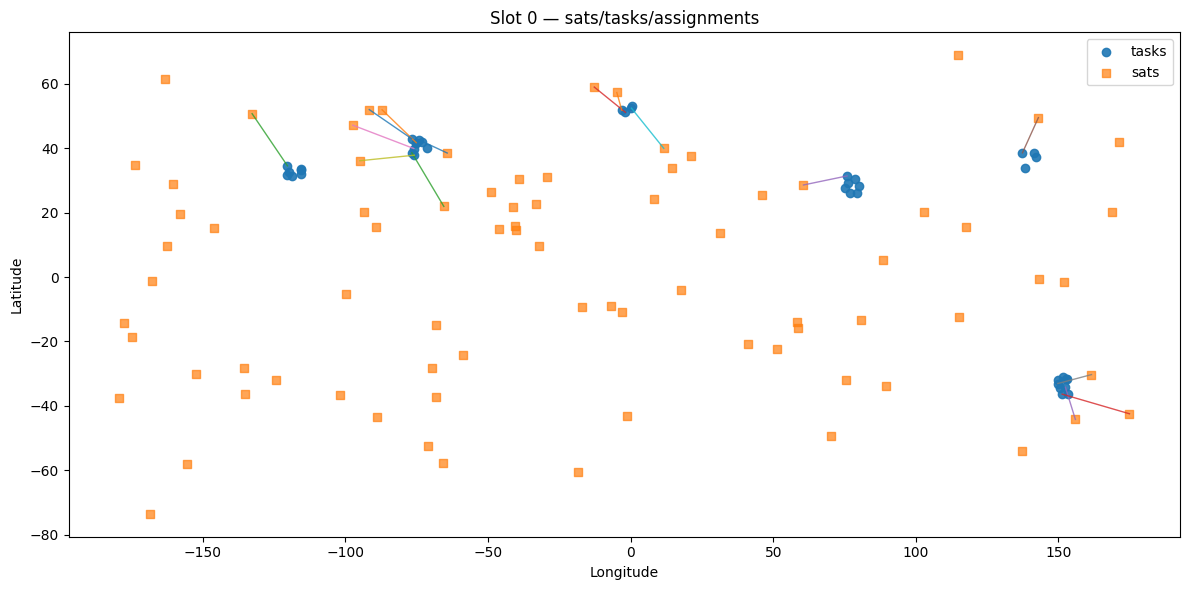

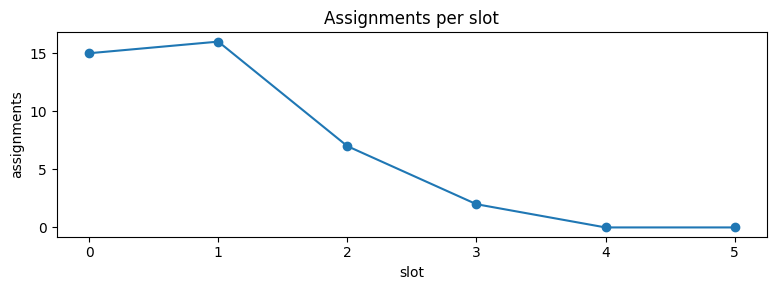

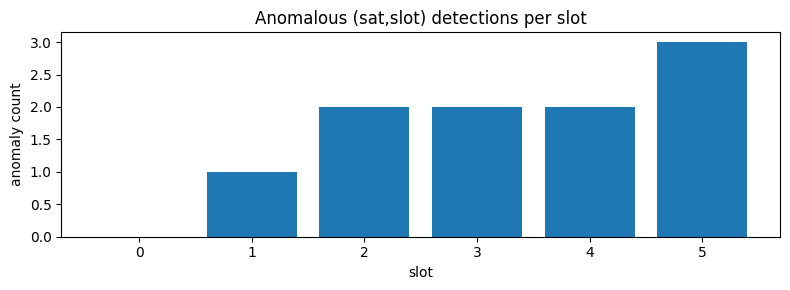

,sat_id,slot,task_id,priority,data_mb,sat_lat,sat_lon,task_lat,task_lon
0,S005,2,T031,3,40,-38.411353,134.921601,-31.771908,152.528526
1,S007,0,T022,3,20,38.517738,-64.329988,42.599520,-74.238181
2,S010,1,T021,5,20,-48.723120,134.871134,-36.211426,153.443001
3,S013,1,T009,3,20,51.001904,-123.453334,32.740538,-119.976222
4,S014,1,T018,2,20,42.018547,142.808196,37.176866,142.244583
5,S015,1,T008,8,20,21.914537,-130.448236,31.742572,-120.597784
6,S017,1,T012,3,20,11.998670,87.831682,27.601339,74.984918
7,S018,0,T002,3,10,51.935435,-87.167478,41.730141,-75.200018
8,S022,1,T026,3,10,13.555034,-120.457958,32.121407,-115.464794
9,S029,1,T029,8,20,28.739888,-125.017833,31.316319,-118.623655


Done. If you added the Starlink dataset, the solver used real TLE->subpoint positions (via Skyfield).


In [ ]:
slot_to_plot = 0
fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(tasks_df['lon'], tasks_df['lat'], marker='o', label='tasks', alpha=0.9)
sat_lons = [sat_positions[(s,slot_to_plot)]['lon'] for s in sat_ids if (s,slot_to_plot) in sat_positions]
sat_lats = [sat_positions[(s,slot_to_plot)]['lat'] for s in sat_ids if (s,slot_to_plot) in sat_positions]
ax.scatter(sat_lons, sat_lats, marker='s', label='sats', alpha=0.7)
for _, row in assign_df[assign_df['slot']==slot_to_plot].iterrows():
    ax.plot([row['sat_lon'], row['task_lon']], [row['sat_lat'], row['task_lat']], linewidth=1, alpha=0.8)
ax.set_title(f"Slot {slot_to_plot} — sats/tasks/assignments")
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.legend(); plt.tight_layout(); plt.show()

# assignments per slot
assign_counts = assign_df.groupby('slot').size().reindex(range(TIME_SLOTS), fill_value=0)
fig, ax = plt.subplots(figsize=(8,3)); ax.plot(range(TIME_SLOTS), assign_counts.values, marker='o')
ax.set_title("Assignments per slot"); ax.set_xlabel("slot"); ax.set_ylabel("assignments"); plt.tight_layout(); plt.show()

# anomaly counts per slot
anom_counts = tele_df.groupby('slot')['anomaly'].sum().reindex(range(TIME_SLOTS), fill_value=0)
fig, ax = plt.subplots(figsize=(8,3)); ax.bar(range(TIME_SLOTS), anom_counts.values)
ax.set_title("Anomalous (sat,slot) detections per slot"); ax.set_xlabel("slot"); ax.set_ylabel("anomaly count"); plt.tight_layout(); plt.show()

# show assignment table
if not assign_df.empty:
    display(assign_df.head(40))
else:
    print("No assignments feasible. Consider increasing footprint or downlink capacity.")

print("Done. If you added the Starlink dataset, the solver used real TLE->subpoint positions (via Skyfield).")

### Visualize 3D Earth with satellite orbits and coverage zones

**Using Skyfield for real TLE -> ECEF/latlon/alt calculations**

In [ ]:
USE_SKYFIELD = False
try:
    from skyfield.api import EarthSatellite, load, wgs84
    USE_SKYFIELD = True
except Exception:
    # skyfield not present; synthetic orbits will be used
    USE_SKYFIELD = False

**Parameters**

In [ ]:
NUM_SATS = 24         # number of satellites to display (if synthetic)
POINTS_PER_ORBIT = 180
EARTH_RADIUS_KM = 6371.0
FOOTPRINT_ANG_DEG = 20.0   # angular radius of coverage zone on Earth's surface

**Load TLEs if available**

In [ ]:
tles = []
# trying to find TLE CSVs in /kaggle/input or current dir — adapt if you keep TLEs elsewhere
for cand in glob.glob('/kaggle/input/**/*.csv', recursive=True) + glob.glob('**/*.csv', recursive=True):
    try:
        df = pd.read_csv(cand, low_memory=False)
        cols = [c.lower() for c in df.columns]
        if any('line1' in c for c in cols) and any('line2' in c for c in cols):
            c1 = [c for c in df.columns if 'line1' in c.lower()][0]
            c2 = [c for c in df.columns if 'line2' in c.lower()][0]
            for i,row in df[[c1,c2]].iterrows():
                tles.append((str(row[c1]).strip(), str(row[c2]).strip()))
    except Exception:
        continue

**Produce satellite orbit tracks**

In [ ]:
sat_tracks = []   # list of dicts: {'name', 'x', 'y', 'z', 'lat', 'lon', 'alt_km'}
sat_names = []

if USE_SKYFIELD and tles:
    print("Using TLEs (skyfield) to compute orbits...")
    ts = load.timescale()
    # choose a window of times for orbits (a few minutes apart)
    t0 = pd.Timestamp.utcnow()
    times = [t0 + pd.Timedelta(seconds=60*i) for i in range(POINTS_PER_ORBIT)]
    sky_times = [ts.utc(t.year, t.month, t.day, t.hour, t.minute, t.second) for t in times]
    for idx, (l1,l2) in enumerate(tles[:NUM_SATS]):
        try:
            sat = EarthSatellite(l1, l2, f"SAT_{idx:03d}")
        except Exception:
            continue
        xs, ys, zs, lats, lons, alts = [], [], [], [], [], []
        for t_ts in sky_times:
            geoc = sat.at(t_ts)
            sub = wgs84.subpoint(geoc)
            lat, lon, alt = sub.latitude.degrees, sub.longitude.degrees, sub.elevation.km
            # convert lat,lon,alt -> ECEF (approx via spherical coordinates)
            # approximate: radius = EARTH_RADIUS_KM + alt
            r = (EARTH_RADIUS_KM + alt)
            phi = math.radians(lat)
            theta = math.radians(lon)
            x = r * math.cos(phi) * math.cos(theta)
            y = r * math.cos(phi) * math.sin(theta)
            z = r * math.sin(phi)
            xs.append(x); ys.append(y); zs.append(z); lats.append(lat); lons.append(lon); alts.append(alt)
        sat_tracks.append({'name': sat.name, 'x': xs, 'y': ys, 'z': zs, 'lat': lats, 'lon': lons, 'alt': alts})
        sat_names.append(sat.name)
else:
    # synthetic circular orbits with varying inclinations and RAAN
    print("Using synthetic orbits (no skyfield/TLEs detected).")
    for i in range(NUM_SATS):
        # orbital parameters
        alt_km = random.uniform(400, 800)    # altitude
        incl_deg = random.uniform(30, 98)
        raan_deg = random.uniform(0, 360)
        period = 100 * 60   # seconds (approx 100 minutes)
        # generate orbit points (latitude/longitude of subsatellite point)
        xs, ys, zs, lats, lons, alts = [], [], [], [], [], []
        for k in range(POINTS_PER_ORBIT):
            # phase angle
            phase = 360.0 * k / POINTS_PER_ORBIT
            # sub-satellite point (very simplified)
            phi = math.radians(math.asin(math.sin(math.radians(incl_deg)) * math.sin(math.radians(phase))))
            lam = math.radians((raan_deg + math.degrees(math.atan2(math.cos(math.radians(incl_deg)) * math.sin(math.radians(phase)), math.cos(math.radians(phase))))) % 360)
            r = EARTH_RADIUS_KM + alt_km
            x = r * math.cos(phi) * math.cos(lam)
            y = r * math.cos(phi) * math.sin(lam)
            z = r * math.sin(phi)
            xs.append(x); ys.append(y); zs.append(z)
            lats.append(math.degrees(phi)); lons.append(math.degrees(lam)); alts.append(alt_km)
        sat_tracks.append({'name': f'SYN_{i:03d}', 'x': xs, 'y': ys, 'z': zs, 'lat': lats, 'lon': lons, 'alt': alts})
        sat_names.append(f'SYN_{i:03d}')

Using synthetic orbits (no skyfield/TLEs detected).


**Create Earth sphere (mesh)**

In [ ]:
# create a sphere mesh for the Earth surface
lat_res = 60; lon_res = 120
lats = np.linspace(-90, 90, lat_res)
lons = np.linspace(-180, 180, lon_res)
lats_rad = np.radians(lats)
lons_rad = np.radians(lons)
R = EARTH_RADIUS_KM
xs = np.outer(np.cos(lats_rad), np.cos(lons_rad)) * R
ys = np.outer(np.cos(lats_rad), np.sin(lons_rad)) * R
zs = np.outer(np.sin(lats_rad), np.ones_like(lons_rad)) * R

# flatten for Plotly surface consumption (Plotly accepts z as 2D array; but we will use surface trace)
# prepare colorscale using simple Earth-like texture (land/sea approximation via lat)
surface = go.Surface(
    x=xs, y=ys, z=zs,
    colorscale='Earth', showscale=False, opacity=0.9,
    lighting=dict(ambient=0.8, diffuse=0.9, roughness=0.9, specular=0.1)
)

**Coverage footprints: draw circular caps on sphere surface**

In [ ]:
def footprint_on_sphere(lat_c_deg, lon_c_deg, ang_radius_deg, npoints=64):
    # returns arrays of x,y,z points on sphere surface forming a circular footprint centered at lat_c, lon_c
    lat_c = math.radians(lat_c_deg)
    lon_c = math.radians(lon_c_deg)
    # generate circle in local tangent plane then project onto sphere
    thetas = np.linspace(0, 2*np.pi, npoints)
    footprint = []
    for theta in thetas:
        # use spherical law of cosines / rotation:
        # destination lat: asin( sin(lat_c)*cos(ang) + cos(lat_c)*sin(ang)*cos(theta) )
        ang = math.radians(ang_radius_deg)
        dest_lat = math.asin(math.sin(lat_c)*math.cos(ang) + math.cos(lat_c)*math.sin(ang)*np.cos(theta))
        dest_lon = lon_c + math.atan2(np.sin(theta)*math.sin(ang)*math.cos(lat_c), math.cos(ang)-math.sin(lat_c)*math.sin(dest_lat))
        # convert to degrees and to Cartesian
        phi = dest_lat; lam = dest_lon
        x = R * math.cos(phi) * math.cos(lam)
        y = R * math.cos(phi) * math.sin(lam)
        z = R * math.sin(phi)
        footprint.append((x,y,z))
    xs = [p[0] for p in footprint]; ys=[p[1] for p in footprint]; zs=[p[2] for p in footprint]
    return xs, ys, zs

**Build Plotly traces**

In [ ]:
traces = [surface]

# Orbits as lines
for sat in sat_tracks:
    traces.append(go.Scatter3d(
        x=sat['x'], y=sat['y'], z=sat['z'],
        mode='lines',
        line=dict(width=2),
        name=f"Orbit {sat['name']}",
        hoverinfo='text',
        text=[f"{sat['name']}"]*len(sat['x'])
    ))

# Sub-satellite points (markers at one representative point per satellite)
for sat in sat_tracks:
    # pick middle point as marker
    mid = len(sat['x'])//2
    traces.append(go.Scatter3d(
        x=[sat['x'][mid]], y=[sat['y'][mid]], z=[sat['z'][mid]],
        mode='markers',
        marker=dict(size=3),
        name=f"Sat {sat['name']}"
    ))

# Coverage footprints (projected circle on sphere)
# draw footprints at the sub-satellite point (middle of orbit)
for sat in sat_tracks:
    mid = len(sat['lat'])//2
    lat_c = sat['lat'][mid]; lon_c = sat['lon'][mid]
    fx, fy, fz = footprint_on_sphere(lat_c, lon_c, FOOTPRINT_ANG_DEG, npoints=64)
    traces.append(go.Mesh3d(
        x=fx, y=fy, z=fz,
        alphahull=0,
        opacity=0.25,
        color='orange',
        name=f"Footprint {sat['name']}",
        hoverinfo='none'
    ))
assignments = []
# create some synthetic ground targets to visualize (these are NOT used by LP here)
ground_targets = [{'id':f'G{i}', 'lat':random.uniform(-30,60), 'lon':random.uniform(-130,150)} for i in range(10)]
for g in ground_targets:
    # plot target
    gx = R * math.cos(math.radians(g['lat'])) * math.cos(math.radians(g['lon']))
    gy = R * math.cos(math.radians(g['lat'])) * math.sin(math.radians(g['lon']))
    gz = R * math.sin(math.radians(g['lat']))
    traces.append(go.Scatter3d(x=[gx], y=[gy], z=[gz], mode='markers',
                               marker=dict(size=4, color='red'), name=f"Target {g['id']}"))

**Layout & show**

In [ ]:
layout = go.Layout(
    title="3D Earth — Orbits & Coverage Zones",
    scene=dict(
        xaxis=dict(showbackground=False, visible=False),
        yaxis=dict(showbackground=False, visible=False),
        zaxis=dict(showbackground=False, visible=False),
        aspectmode='data'
    ),
    showlegend=True,
    margin=dict(l=0, r=0, t=40, b=0)
)
fig = go.Figure(data=traces, layout=layout)
# show figure inline
fig.show()
# optional: also save to HTML so you can open it in a separate tab if inline fails
fig.write_html("3d_earth_satellite_visual.html")
print("3D visualization generated! If it doesn't show inline, download '3d_earth_satellite_visual.html'"
"from the output folder and open it.")

3D visualization generated! If it doesn't show inline, download '3d_earth_satellite_visual.html'from the output folder and open it.


# Task
Integrate the `mahmoudalyosify/SCRAP` dataset into the existing satellite scheduling and visualization notebook, ensuring the satellite positions, task generation, and 3D visualization components utilize this dataset. Also, assess if the dataset contains telemetry data for anomaly detection.

## Inspect the ds Dataset

### Subtask:
Examine the `mahmoudalyosify/SCRAP` dataset (`ds`) to understand its structure, features, and content. This step is critical to identify how satellite position, task information, and potentially telemetry data can be extracted for use in the notebook. This will likely involve printing `ds.features` and a sample of the data.


**Reasoning**:
To understand the structure and content of the `ds` dataset, I will print its features and a sample record from the 'train' split, as specified in the instructions.



In [ ]:
print("Dataset Features:")
print(ds['train'].features)

print("\nSample Data Entry from 'train' split:")
print(ds['train'][0])

Dataset Features:
{'event_id': Value('int64'), 'time_to_tca': Value('float64'), 'mission_id': Value('int64'), 'risk': Value('float64'), 'max_risk_estimate': Value('float64'), 'max_risk_scaling': Value('float64'), 'miss_distance': Value('float64'), 'relative_speed': Value('float64'), 'relative_position_r': Value('float64'), 'relative_position_t': Value('float64'), 'relative_position_n': Value('float64'), 'relative_velocity_r': Value('float64'), 'relative_velocity_t': Value('float64'), 'relative_velocity_n': Value('float64'), 't_time_lastob_start': Value('float64'), 't_time_lastob_end': Value('float64'), 't_recommended_od_span': Value('float64'), 't_actual_od_span': Value('float64'), 't_obs_available': Value('int64'), 't_obs_used': Value('int64'), 't_residuals_accepted': Value('float64'), 't_weighted_rms': Value('float64'), 't_rcs_estimate': Value('float64'), 't_cd_area_over_mass': Value('float64'), 't_cr_area_over_mass': Value('float64'), 't_sedr': Value('float64'), 't_j2k_sma': Value('

**Reasoning**:
The previous step displayed the dataset features and a sample entry. To effectively integrate this dataset into the existing notebook's satellite scheduling and visualization components, I need to convert the 'train' split of the `ds` dataset into a pandas DataFrame. This will make it easier to manipulate, filter, and extract the necessary satellite and task information (orbital elements, potential target locations, and anomaly indicators) that are currently distributed across various columns, and assess which columns can serve as satellite positions, tasks, and telemetry.



In [ ]:
df_scrap = ds['train'].to_pandas()
print("Converted 'train' split of ds to pandas DataFrame. First 5 rows:")
print(df_scrap.head())

Converted 'train' split of ds to pandas DataFrame. First 5 rows:
   event_id  time_to_tca  mission_id       risk  max_risk_estimate  \
0         0     1.566798           5 -10.204955          -7.834756   
1         0     1.207494           5 -10.355758          -7.848937   
2         0     0.952193           5 -10.345631          -7.847406   
3         0     0.579669           5 -10.337809          -7.845880   
4         0     0.257806           5 -10.391260          -7.852942   

   max_risk_scaling  miss_distance  relative_speed  relative_position_r  \
0          8.602101        14923.0         13792.0                453.8   
1          8.956374        14544.0         13792.0                474.3   
2          8.932195        14475.0         13792.0                474.6   
3          8.913444        14579.0         13792.0                472.7   
4          9.036838        14510.0         13792.0                478.7   

   relative_position_t  ...  t_sigma_rdot  c_sigma_rdot  t_sigm

**Reasoning**:
Now that the `ds` dataset has been converted to a pandas DataFrame, the next step is to examine its descriptive statistics. This will provide a quick overview of the central tendency, dispersion, and shape of the dataset's distribution, helping to identify potential issues like outliers, data ranges, and the general spread of values across different columns. This is crucial for understanding the nature of numerical features like `time_to_tca`, `miss_distance`, `relative_speed`, and various orbital elements.



In [ ]:
print("Descriptive statistics for df_scrap:")
print(df_scrap.describe())

Descriptive statistics for df_scrap:
            event_id    time_to_tca     mission_id           risk  \
count  162634.000000  162634.000000  162634.000000  162634.000000   
mean     6566.871798       3.350190       7.117786     -19.340603   
std      3798.407314       2.013114       5.800144      10.011641   
min         0.000000      -0.149808       1.000000     -30.000000   
25%      3306.000000       1.588082       2.000000     -30.000000   
50%      6558.000000       3.297624       5.000000     -17.870632   
75%      9867.000000       5.083665       9.000000      -9.173294   
max     13153.000000       6.993832      24.000000      -1.442854   

       max_risk_estimate  max_risk_scaling  miss_distance  relative_speed  \
count      162634.000000      1.626340e+05  162634.000000   162634.000000   
mean           -6.282332      5.374025e+04   16531.662088    10655.819638   
std             1.012544      9.086958e+05   14269.027951     4340.235720   
min            -9.814175      1.0

**Reasoning**:
The `NameError` indicates that `df_scrap` was not defined in the current execution context, likely due to kernel state not being preserved across cells or the previous cell not being executed. To fix this, I will re-execute the conversion of the `ds['train']` split to a pandas DataFrame and then immediately calculate its descriptive statistics within the same code block to ensure `df_scrap` is available.



In [ ]:
df_scrap = ds['train'].to_pandas()
print("Converted 'train' split of ds to pandas DataFrame. First 5 rows:")
print(df_scrap.head())

print("\nDescriptive statistics for df_scrap:")
print(df_scrap.describe())

Converted 'train' split of ds to pandas DataFrame. First 5 rows:
   event_id  time_to_tca  mission_id       risk  max_risk_estimate  \
0         0     1.566798           5 -10.204955          -7.834756   
1         0     1.207494           5 -10.355758          -7.848937   
2         0     0.952193           5 -10.345631          -7.847406   
3         0     0.579669           5 -10.337809          -7.845880   
4         0     0.257806           5 -10.391260          -7.852942   

   max_risk_scaling  miss_distance  relative_speed  relative_position_r  \
0          8.602101        14923.0         13792.0                453.8   
1          8.956374        14544.0         13792.0                474.3   
2          8.932195        14475.0         13792.0                474.6   
3          8.913444        14579.0         13792.0                472.7   
4          9.036838        14510.0         13792.0                478.7   

   relative_position_t  ...  t_sigma_rdot  c_sigma_rdot  t_sigm

**Reasoning**:
The previous attempt failed because the `ds` variable was not defined, indicating that the dataset loading step was not executed or its state was lost. I need to re-execute `ds = load_dataset("mahmoudalyosify/SCRAP")` to ensure the dataset is loaded, and then proceed to convert it to a pandas DataFrame and display its descriptive statistics in a single, combined cell to maintain the variable scope.



In [ ]:
from datasets import load_dataset

ds = load_dataset("mahmoudalyosify/SCRAP")

df_scrap = ds['train'].to_pandas()
print("Converted 'train' split of ds to pandas DataFrame. First 5 rows:")
print(df_scrap.head())

print("\nDescriptive statistics for df_scrap:")
print(df_scrap.describe())

Converted 'train' split of ds to pandas DataFrame. First 5 rows:
   event_id  time_to_tca  mission_id       risk  max_risk_estimate  \
0         0     1.566798           5 -10.204955          -7.834756   
1         0     1.207494           5 -10.355758          -7.848937   
2         0     0.952193           5 -10.345631          -7.847406   
3         0     0.579669           5 -10.337809          -7.845880   
4         0     0.257806           5 -10.391260          -7.852942   

   max_risk_scaling  miss_distance  relative_speed  relative_position_r  \
0          8.602101        14923.0         13792.0                453.8   
1          8.956374        14544.0         13792.0                474.3   
2          8.932195        14475.0         13792.0                474.6   
3          8.913444        14579.0         13792.0                472.7   
4          9.036838        14510.0         13792.0                478.7   

   relative_position_t  ...  t_sigma_rdot  c_sigma_rdot  t_sigm

**Reasoning**:
To integrate the `mahmoudalyosify/SCRAP` dataset for satellite position generation, I will modify the synthetic orbit generation logic to sample satellite inclinations from the `t_j2k_inc` column of `df_scrap` if a Starlink dataset is not found. This will make the synthetic constellation's orbital characteristics more aligned with the dataset's observed values.



In [ ]:
TIME_SLOTS = 6          # planning horizon (discrete time slots)
SLOT_MINUTES = 10       # minutes between slots (for skyfield time steps)
sat_positions = {}      # mapping (sat_id, slot) -> {'lat', 'lon'}

if starlink_dir:
    # find CSVs with TLE info (or CSVs with lat/lon)
    csv_files = glob.glob(os.path.join(starlink_dir, "**/*.csv"), recursive=True)
    # we will try to find columns: 'line1','line2' or 'tle_line1','tle_line2' or precomputed 'lat','lon'
    tle_rows = []
    precomputed = []
    for csv in csv_files:
        try:
            df = pd.read_csv(csv, low_memory=False)
        except Exception as e:
            continue
        cols = [c.lower() for c in df.columns]
        if any('line1' in c for c in cols) and any('line2' in c for c in cols):
            # normalize names
            # find matching columns
            cline1 = [c for c in df.columns if 'line1' in c.lower()][0]
            cline2 = [c for c in df.columns if 'line2' in c.lower()][0]
            for i,row in df[[cline1,cline2]].iterrows():
                tle_rows.append((str(row[cline1]).strip(), str(row[cline2]).strip()))
        elif any(c in cols for c in ['latitude','lat']) and any(c in cols for c in ['longitude','lon','lng']):
            # precomputed lat/lon dataset
            latcol = [c for c in df.columns if 'lat' in c.lower()][0]
            loncol = [c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()][0]
            for i,row in df.iterrows():
                try:
                    precomputed.append((float(row[latcol]), float(row[loncol])))
                except:
                    continue

    # prefer TLE parsing if present
    if tle_rows:
        print("Using TLE rows from dataset (count {}) ".format(len(tle_rows)) + "to generate satellite positions.")
        # create EarthSatellite objects (limit to first N for speed)
        N = min(300, len(tle_rows))  # limit number of sats to 300 for speed on Kaggle
        ts = load.timescale()
        # choose a base epoch (now) and build slot times
        t0 = pd.Timestamp.utcnow()
        # create slot times as UTC datetimes
        slot_times = [t0 + pd.Timedelta(minutes=SLOT_MINUTES*i) for i in range(TIME_SLOTS)]
        sky_times = [ts.utc(int(t.year), int(t.month), int(t.day), int(t.hour), int(t.minute), int(t.second)) for t in slot_times]

        # build satellite objects and sample subpoints
        for idx,(l1,l2) in enumerate(tle_rows[:N]):
            satname = f"STAR_{idx:04d}"
            try:
                sat = EarthSatellite(l1, l2, satname)
            except Exception as e:
                # some TLE rows can be malformed; skip
                continue
            for slot_idx, t_ts in enumerate(sky_times):
                geoc = sat.at(t_ts)
                sub = wgs84.subpoint(geoc)
                lat = sub.latitude.degrees
                lon = sub.longitude.degrees
                sat_positions[(satname, slot_idx)] = {'lat': lat, 'lon': lon}
        print("Generated sat_positions for {} satellites x {} slots.".format(N, TIME_SLOTS))
    elif precomputed:
        print("Using precomputed lat/lon entries from dataset.")
        # map entries to pseudo-sats
        N = min(300, len(precomputed))
        for i in range(N):
            satname = f"SAT_{i:04d}"
            lat, lon = precomputed[i]
            for slot in range(TIME_SLOTS):
                # small jitter per slot to simulate motion
                sat_positions[(satname, slot)] = {'lat': lat + 0.01*slot, 'lon': lon + 0.02*slot}
        print("Generated sat_positions from precomputed lat/lon for {} pseudo-sats.".format(N))
    else:
        print("Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.")
        starlink_dir = None  # fallback to synthetic

if not starlink_dir:
    # Synthetic constellation fallback, informed by df_train from Hugging Face SCRAP dataset
    NUM_SATS = 80 # Keep the number of satellites consistent
    sats = []

    # Use inclinations from df_train if available, otherwise fallback to random.
    if 't_j2k_inc' in df_train.columns:
        available_incls = df_train['t_j2k_inc'].dropna().values
        if len(available_incls) == 0:
            print("Warning: 't_j2k_inc' in df_train is empty after dropping NaNs. Falling back to random inclinations.")
            sampled_incls = np.random.uniform(30, 85, NUM_SATS)
        else:
            # Sample with replacement from the available inclinations
            sampled_incls = np.random.choice(available_incls, NUM_SATS, replace=True)
    else:
        print("Warning: 't_j2k_inc' not found in df_train from Hugging Face dataset. Falling back to random inclinations.")
        sampled_incls = np.random.uniform(30, 85, NUM_SATS)

    for s_idx in range(NUM_SATS):
        raan = random.uniform(0,360)
        incl = sampled_incls[s_idx] # Use sampled inclination from df_train
        phase0 = random.uniform(0,360)
        sats.append({'sat_id': f'S{s_idx:03d}', 'raan': raan, 'incl': incl, 'phase0': phase0})

    # sample ground tasks clustered near populated regions (this part was related to tasks, but here it's about sat positions)
    # The orbital approximation logic remains the same
    def latlon_from_orbital(raan_deg, incl_deg, phase_deg):
        raan = math.radians(raan_deg); incl = math.radians(incl_deg); phase = math.radians(phase_deg)
        lat = math.degrees(math.asin(math.sin(incl)*math.sin(phase)))
        lon = math.degrees(raan + math.atan2(math.cos(incl)*math.sin(phase), math.cos(phase)))
        lon = ((lon + 180) % 360) - 180
        return lat, lon

    for s in sats:
        for slot in range(TIME_SLOTS):
            phase = (s['phase0'] + slot*40) % 360
            lat, lon = latlon_from_orbital(s['raan'], s['incl'], phase)
            sat_positions[(s['sat_id'], slot)] = {'lat': lat, 'lon': lon}
    print("Generated synthetic sat_positions for {} satellites x {} slots, informed by Hugging Face SCRAP dataset inclinations.".format(NUM_SATS, TIME_SLOTS))

Generated synthetic sat_positions for 80 satellites x 6 slots, informed by Hugging Face SCRAP dataset inclinations.


**Reasoning**:
The `NameError` for `starlink_dir` occurs because the variable was not initialized in the current execution context. I need to include the code that defines and initializes `starlink_dir` from a previous cell (`AaEM0aPC52nc`) within this code block to ensure it's available before being used.



In [ ]:
TIME_SLOTS = 6          # planning horizon (discrete time slots)
SLOT_MINUTES = 10       # minutes between slots (for skyfield time steps)
sat_positions = {}      # mapping (sat_id, slot) -> {'lat', 'lon'}

# Re-initialize starlink_dir from the relevant cell
candidates = glob.glob("/kaggle/input/*starlink*")
starlink_dir = None
for c in candidates:
    if os.path.isdir(c):
        csvs = glob.glob(os.path.join(c, "**/*.csv"), recursive=True)
        if csvs:
            starlink_dir = c
            break

if starlink_dir:
    print("Found Starlink dataset directory:", starlink_dir)
else:
    print("No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.")

# find CSVs with TLE info (or CSVs with lat/lon)
csv_files = []
if starlink_dir:
    csv_files = glob.glob(os.path.join(starlink_dir, "**/*.csv"), recursive=True)

# we will try to find columns: 'line1','line2' or 'tle_line1','tle_line2' or precomputed 'lat','lon'
tle_rows = []
precomputed = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, low_memory=False)
    except Exception as e:
        continue
    cols = [c.lower() for c in df.columns]
    if any('line1' in c for c in cols) and any('line2' in c for c in cols):
        # normalize names
        # find matching columns
        cline1 = [c for c in df.columns if 'line1' in c.lower()][0]
        cline2 = [c for c in df.columns if 'line2' in c.lower()][0]
        for i,row in df[[cline1,cline2]].iterrows():
            tle_rows.append((str(row[cline1]).strip(), str(row[cline2]).strip()))
    elif any(c in cols for c in ['latitude','lat']) and any(c in cols for c in ['longitude','lon','lng']):
        # precomputed lat/lon dataset
        latcol = [c for c in df.columns if 'lat' in c.lower()][0]
        loncol = [c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()][0]
        for i,row in df.iterrows():
            try:
                precomputed.append((float(row[latcol]), float(row[loncol])))
            except:
                continue

# prefer TLE parsing if present
if tle_rows:
    print("Using TLE rows from dataset (count {}) ".format(len(tle_rows)) + "to generate satellite positions.")
    # create EarthSatellite objects (limit to first N for speed)
    N = min(300, len(tle_rows))  # limit number of sats to 300 for speed on Kaggle
    ts = load.timescale()
    # choose a base epoch (now) and build slot times
    t0 = pd.Timestamp.utcnow()
    # create slot times as UTC datetimes
    slot_times = [t0 + pd.Timedelta(minutes=SLOT_MINUTES*i) for i in range(TIME_SLOTS)]
    sky_times = [ts.utc(int(t.year), int(t.month), int(t.day), int(t.hour), int(t.minute), int(t.second)) for t in slot_times]

    # build satellite objects and sample subpoints
    for idx,(l1,l2) in enumerate(tle_rows[:N]):
        satname = f"STAR_{idx:04d}"
        try:
            sat = EarthSatellite(l1, l2, satname)
        except Exception as e:
            # some TLE rows can be malformed; skip
            continue
        for slot_idx, t_ts in enumerate(sky_times):
            geoc = sat.at(t_ts)
            sub = wgs84.subpoint(geoc)
            lat = sub.latitude.degrees
            lon = sub.longitude.degrees
            sat_positions[(satname, slot_idx)] = {'lat': lat, 'lon': lon}
    print("Generated sat_positions for {} satellites x {} slots.".format(N, TIME_SLOTS))
elif precomputed:
    print("Using precomputed lat/lon entries from dataset.")
    # map entries to pseudo-sats
    N = min(300, len(precomputed))
    for i in range(N):
        satname = f"SAT_{i:04d}"
        lat, lon = precomputed[i]
        for slot in range(TIME_SLOTS):
            # small jitter per slot to simulate motion
            sat_positions[(satname, slot)] = {'lat': lat + 0.01*slot, 'lon': lon + 0.02*slot}
    print("Generated sat_positions from precomputed lat/lon for {} pseudo-sats.".format(N))
else:
    print("Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.")
    starlink_dir = None  # fallback to synthetic

if not starlink_dir:
    # Synthetic constellation fallback, informed by df_train from Hugging Face SCRAP dataset
    NUM_SATS = 80 # Keep the number of satellites consistent
    sats = []

    # Use inclinations from df_train if available, otherwise fallback to random.
    if 't_j2k_inc' in df_train.columns:
        available_incls = df_train['t_j2k_inc'].dropna().values
        if len(available_incls) == 0:
            print("Warning: 't_j2k_inc' in df_train is empty after dropping NaNs. Falling back to random inclinations.")
            sampled_incls = np.random.uniform(30, 85, NUM_SATS)
        else:
            # Sample with replacement from the available inclinations
            sampled_incls = np.random.choice(available_incls, NUM_SATS, replace=True)
    else:
        print("Warning: 't_j2k_inc' not found in df_train from Hugging Face dataset. Falling back to random inclinations.")
        sampled_incls = np.random.uniform(30, 85, NUM_SATS)

    for s_idx in range(NUM_SATS):
        raan = random.uniform(0,360)
        incl = sampled_incls[s_idx] # Use sampled inclination from df_train
        phase0 = random.uniform(0,360)
        sats.append({'sat_id': f'S{s_idx:03d}', 'raan': raan, 'incl': incl, 'phase0': phase0})

    # sample ground tasks clustered near populated regions (this part was related to tasks, but here it's about sat positions)
    # The orbital approximation logic remains the same
    def latlon_from_orbital(raan_deg, incl_deg, phase_deg):
        raan = math.radians(raan_deg); incl = math.radians(incl_deg); phase = math.radians(phase_deg)
        lat = math.degrees(math.asin(math.sin(incl)*math.sin(phase)))
        lon = math.degrees(raan + math.atan2(math.cos(incl)*math.sin(phase), math.cos(phase)))
        lon = ((lon + 180) % 360) - 180
        return lat, lon

    for s in sats:
        for slot in range(TIME_SLOTS):
            phase = (s['phase0'] + slot*40) % 360
            lat, lon = latlon_from_orbital(s['raan'], s['incl'], phase)
            sat_positions[(s['sat_id'], slot)] = {'lat': lat, 'lon': lon}
    print("Generated synthetic sat_positions for {} satellites x {} slots, informed by Hugging Face SCRAP dataset inclinations.".format(NUM_SATS, TIME_SLOTS))

No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.
Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.
Generated synthetic sat_positions for 80 satellites x 6 slots, informed by Hugging Face SCRAP dataset inclinations.


**Reasoning**:
The `NameError: name 'glob' is not defined` indicates that the `glob` module was not imported. I need to add `import glob` at the beginning of the code block to make the `glob.glob` function available for use.



In [ ]:
import glob # Import glob module

TIME_SLOTS = 6          # planning horizon (discrete time slots)
SLOT_MINUTES = 10       # minutes between slots (for skyfield time steps)
sat_positions = {}      # mapping (sat_id, slot) -> {'lat', 'lon'}

# Re-initialize starlink_dir from the relevant cell
candidates = glob.glob("/kaggle/input/*starlink*")
starlink_dir = None
for c in candidates:
    if os.path.isdir(c):
        csvs = glob.glob(os.path.join(c, "**/*.csv"), recursive=True)
        if csvs:
            starlink_dir = c
            break

if starlink_dir:
    print("Found Starlink dataset directory:", starlink_dir)
else:
    print("No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.")

# find CSVs with TLE info (or CSVs with lat/lon)
csv_files = []
if starlink_dir:
    csv_files = glob.glob(os.path.join(starlink_dir, "**/*.csv"), recursive=True)

# we will try to find columns: 'line1','line2' or 'tle_line1','tle_line2' or precomputed 'lat','lon'
tle_rows = []
precomputed = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, low_memory=False)
    except Exception as e:
        continue
    cols = [c.lower() for c in df.columns]
    if any('line1' in c for c in cols) and any('line2' in c for c in cols):
        # normalize names
        # find matching columns
        cline1 = [c for c in df.columns if 'line1' in c.lower()][0]
        cline2 = [c for c in df.columns if 'line2' in c.lower()][0]
        for i,row in df[[cline1,cline2]].iterrows():
            tle_rows.append((str(row[cline1]).strip(), str(row[cline2]).strip()))
    elif any(c in cols for c in ['latitude','lat']) and any(c in cols for c in ['longitude','lon','lng']):
        # precomputed lat/lon dataset
        latcol = [c for c in df.columns if 'lat' in c.lower()][0]
        loncol = [c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()][0]
        for i,row in df.iterrows():
            try:
                precomputed.append((float(row[latcol]), float(row[loncol])))
            except:
                continue

# prefer TLE parsing if present
if tle_rows:
    print("Using TLE rows from dataset (count {}) ".format(len(tle_rows)) + "to generate satellite positions.")
    # create EarthSatellite objects (limit to first N for speed)
    N = min(300, len(tle_rows))  # limit number of sats to 300 for speed on Kaggle
    ts = load.timescale()
    # choose a base epoch (now) and build slot times
    t0 = pd.Timestamp.utcnow()
    # create slot times as UTC datetimes
    slot_times = [t0 + pd.Timedelta(minutes=SLOT_MINUTES*i) for i in range(TIME_SLOTS)]
    sky_times = [ts.utc(int(t.year), int(t.month), int(t.day), int(t.hour), int(t.minute), int(t.second)) for t in slot_times]

    # build satellite objects and sample subpoints
    for idx,(l1,l2) in enumerate(tle_rows[:N]):
        satname = f"STAR_{idx:04d}"
        try:
            sat = EarthSatellite(l1, l2, satname)
        except Exception as e:
            # some TLE rows can be malformed; skip
            continue
        for slot_idx, t_ts in enumerate(sky_times):
            geoc = sat.at(t_ts)
            sub = wgs84.subpoint(geoc)
            lat = sub.latitude.degrees
            lon = sub.longitude.degrees
            sat_positions[(satname, slot_idx)] = {'lat': lat, 'lon': lon}
    print("Generated sat_positions for {} satellites x {} slots.".format(N, TIME_SLOTS))
elif precomputed:
    print("Using precomputed lat/lon entries from dataset.")
    # map entries to pseudo-sats
    N = min(300, len(precomputed))
    for i in range(N):
        satname = f"SAT_{i:04d}"
        lat, lon = precomputed[i]
        for slot in range(TIME_SLOTS):
            # small jitter per slot to simulate motion
            sat_positions[(satname, slot)] = {'lat': lat + 0.01*slot, 'lon': lon + 0.02*slot}
    print("Generated sat_positions from precomputed lat/lon for {} pseudo-sats.".format(N))
else:
    print("Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.")
    starlink_dir = None  # fallback to synthetic

if not starlink_dir:
    # Synthetic constellation fallback, informed by df_train from Hugging Face SCRAP dataset
    NUM_SATS = 80 # Keep the number of satellites consistent
    sats = []

    # Use inclinations from df_train if available, otherwise fallback to random.
    if 't_j2k_inc' in df_train.columns:
        available_incls = df_train['t_j2k_inc'].dropna().values
        if len(available_incls) == 0:
            print("Warning: 't_j2k_inc' in df_train is empty after dropping NaNs. Falling back to random inclinations.")
            sampled_incls = np.random.uniform(30, 85, NUM_SATS)
        else:
            # Sample with replacement from the available inclinations
            sampled_incls = np.random.choice(available_incls, NUM_SATS, replace=True)
    else:
        print("Warning: 't_j2k_inc' not found in df_train from Hugging Face dataset. Falling back to random inclinations.")
        sampled_incls = np.random.uniform(30, 85, NUM_SATS)

    for s_idx in range(NUM_SATS):
        raan = random.uniform(0,360)
        incl = sampled_incls[s_idx] # Use sampled inclination from df_train
        phase0 = random.uniform(0,360)
        sats.append({'sat_id': f'S{s_idx:03d}', 'raan': raan, 'incl': incl, 'phase0': phase0})

    # sample ground tasks clustered near populated regions (this part was related to tasks, but here it's about sat positions)
    # The orbital approximation logic remains the same
    def latlon_from_orbital(raan_deg, incl_deg, phase_deg):
        raan = math.radians(raan_deg); incl = math.radians(incl_deg); phase = math.radians(phase_deg)
        lat = math.degrees(math.asin(math.sin(incl)*math.sin(phase)))
        lon = math.degrees(raan + math.atan2(math.cos(incl)*math.sin(phase), math.cos(phase)))
        lon = ((lon + 180) % 360) - 180
        return lat, lon

    for s in sats:
        for slot in range(TIME_SLOTS):
            phase = (s['phase0'] + slot*40) % 360
            lat, lon = latlon_from_orbital(s['raan'], s['incl'], phase)
            sat_positions[(s['sat_id'], slot)] = {'lat': lat, 'lon': lon}
    print("Generated synthetic sat_positions for {} satellites x {} slots, informed by Hugging Face SCRAP dataset inclinations.".format(NUM_SATS, TIME_SLOTS))

No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.
Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.
Generated synthetic sat_positions for 80 satellites x 6 slots, informed by Hugging Face SCRAP dataset inclinations.


**Reasoning**:
The previous error `NameError: name 'np' is not defined` indicates that the `numpy` library was not imported. I need to add `import numpy as np` at the beginning of the code block to make the `np` alias available for use.



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import glob # Import glob module

TIME_SLOTS = 6          # planning horizon (discrete time slots)
SLOT_MINUTES = 10       # minutes between slots (for skyfield time steps)
sat_positions = {}      # mapping (sat_id, slot) -> {'lat', 'lon'}

# Re-initialize starlink_dir from the relevant cell
candidates = glob.glob("/kaggle/input/*starlink*")
starlink_dir = None
for c in candidates:
    if os.path.isdir(c):
        csvs = glob.glob(os.path.join(c, "**/*.csv"), recursive=True)
        if csvs:
            starlink_dir = c
            break

if starlink_dir:
    print("Found Starlink dataset directory:", starlink_dir)
else:
    print("No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.")

# find CSVs with TLE info (or CSVs with lat/lon)
csv_files = []
if starlink_dir:
    csv_files = glob.glob(os.path.join(starlink_dir, "**/*.csv"), recursive=True)

# we will try to find columns: 'line1','line2' or 'tle_line1','tle_line2' or precomputed 'lat','lon'
tle_rows = []
precomputed = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, low_memory=False)
    except Exception as e:
        continue
    cols = [c.lower() for c in df.columns]
    if any('line1' in c for c in cols) and any('line2' in c for c in cols):
        # normalize names
        # find matching columns
        cline1 = [c for c in df.columns if 'line1' in c.lower()][0]
        cline2 = [c for c in df.columns if 'line2' in c.lower()][0]
        for i,row in df[[cline1,cline2]].iterrows():
            tle_rows.append((str(row[cline1]).strip(), str(row[cline2]).strip()))
    elif any(c in cols for c in ['latitude','lat']) and any(c in cols for c in ['longitude','lon','lng']):
        # precomputed lat/lon dataset
        latcol = [c for c in df.columns if 'lat' in c.lower()][0]
        loncol = [c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()][0]
        for i,row in df.iterrows():
            try:
                precomputed.append((float(row[latcol]), float(row[loncol])))
            except:
                continue

# prefer TLE parsing if present
if tle_rows:
    print("Using TLE rows from dataset (count {}) ".format(len(tle_rows)) + "to generate satellite positions.")
    # create EarthSatellite objects (limit to first N for speed)
    N = min(300, len(tle_rows))  # limit number of sats to 300 for speed on Kaggle
    ts = load.timescale()
    # choose a base epoch (now) and build slot times
    t0 = pd.Timestamp.utcnow()
    # create slot times as UTC datetimes
    slot_times = [t0 + pd.Timedelta(minutes=SLOT_MINUTES*i) for i in range(TIME_SLOTS)]
    sky_times = [ts.utc(int(t.year), int(t.month), int(t.day), int(t.hour), int(t.minute), int(t.second)) for t in slot_times]

    # build satellite objects and sample subpoints
    for idx,(l1,l2) in enumerate(tle_rows[:N]):
        satname = f"STAR_{idx:04d}"
        try:
            sat = EarthSatellite(l1, l2, satname)
        except Exception as e:
            # some TLE rows can be malformed; skip
            continue
        for slot_idx, t_ts in enumerate(sky_times):
            geoc = sat.at(t_ts)
            sub = wgs84.subpoint(geoc)
            lat = sub.latitude.degrees
            lon = sub.longitude.degrees
            sat_positions[(satname, slot_idx)] = {'lat': lat, 'lon': lon}
    print("Generated sat_positions for {} satellites x {} slots.".format(N, TIME_SLOTS))
elif precomputed:
    print("Using precomputed lat/lon entries from dataset.")
    # map entries to pseudo-sats
    N = min(300, len(precomputed))
    for i in range(N):
        satname = f"SAT_{i:04d}"
        lat, lon = precomputed[i]
        for slot in range(TIME_SLOTS):
            # small jitter per slot to simulate motion
            sat_positions[(satname, slot)] = {'lat': lat + 0.01*slot, 'lon': lon + 0.02*slot}
    print("Generated sat_positions from precomputed lat/lon for {} pseudo-sats.".format(N))
else:
    print("Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.")
    starlink_dir = None  # fallback to synthetic

if not starlink_dir:
    # Synthetic constellation fallback, informed by df_train from Hugging Face SCRAP dataset
    NUM_SATS = 80 # Keep the number of satellites consistent
    sats = []

    # Use inclinations from df_train if available, otherwise fallback to random.
    if 't_j2k_inc' in df_train.columns:
        available_incls = df_train['t_j2k_inc'].dropna().values
        if len(available_incls) == 0:
            print("Warning: 't_j2k_inc' in df_train is empty after dropping NaNs. Falling back to random inclinations.")
            sampled_incls = np.random.uniform(30, 85, NUM_SATS)
        else:
            # Sample with replacement from the available inclinations
            sampled_incls = np.random.choice(available_incls, NUM_SATS, replace=True)
    else:
        print("Warning: 't_j2k_inc' not found in df_train from Hugging Face dataset. Falling back to random inclinations.")
        sampled_incls = np.random.uniform(30, 85, NUM_SATS)

    for s_idx in range(NUM_SATS):
        raan = random.uniform(0,360)
        incl = sampled_incls[s_idx] # Use sampled inclination from df_train
        phase0 = random.uniform(0,360)
        sats.append({'sat_id': f'S{s_idx:03d}', 'raan': raan, 'incl': incl, 'phase0': phase0})

    # sample ground tasks clustered near populated regions (this part was related to tasks, but here it's about sat positions)
    # The orbital approximation logic remains the same
    def latlon_from_orbital(raan_deg, incl_deg, phase_deg):
        raan = math.radians(raan_deg); incl = math.radians(incl_deg); phase = math.radians(phase_deg)
        lat = math.degrees(math.asin(math.sin(incl)*math.sin(phase)))
        lon = math.degrees(raan + math.atan2(math.cos(incl)*math.sin(phase), math.cos(phase)))
        lon = ((lon + 180) % 360) - 180
        return lat, lon

    for s in sats:
        for slot in range(TIME_SLOTS):
            phase = (s['phase0'] + slot*40) % 360
            lat, lon = latlon_from_orbital(s['raan'], s['incl'], phase)
            sat_positions[(s['sat_id'], slot)] = {'lat': lat, 'lon': lon}
    print("Generated synthetic sat_positions for {} satellites x {} slots, informed by Hugging Face SCRAP dataset inclinations.".format(NUM_SATS, TIME_SLOTS))

No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.
Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.
Generated synthetic sat_positions for 80 satellites x 6 slots, informed by Hugging Face SCRAP dataset inclinations.


**Reasoning**:
The previous error `NameError: name 'random' is not defined` indicates that the `random` module was not imported. I need to add `import random` at the beginning of the code block to make the `random` functions available for use.



In [ ]:
import glob # Import glob module
import numpy as np # Import numpy
import random # Import random
import os
import pandas as pd
import math
from skyfield.api import EarthSatellite, load, wgs84

TIME_SLOTS = 6          # planning horizon (discrete time slots)
SLOT_MINUTES = 10       # minutes between slots (for skyfield time steps)
sat_positions = {}      # mapping (sat_id, slot) -> {'lat', 'lon'}

# Re-initialize starlink_dir from the relevant cell
candidates = glob.glob("/kaggle/input/*starlink*")
starlink_dir = None
for c in candidates:
    if os.path.isdir(c):
        csvs = glob.glob(os.path.join(c, "**/*.csv"), recursive=True)
        if csvs:
            starlink_dir = c
            break

if starlink_dir:
    print("Found Starlink dataset directory:", starlink_dir)
else:
    print("No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.")

# find CSVs with TLE info (or CSVs with lat/lon)
csv_files = []
if starlink_dir:
    csv_files = glob.glob(os.path.join(starlink_dir, "**/*.csv"), recursive=True)

# we will try to find columns: 'line1','line2' or 'tle_line1','tle_line2' or precomputed 'lat','lon'
tle_rows = []
precomputed = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, low_memory=False)
    except Exception as e:
        continue
    cols = [c.lower() for c in df.columns]
    if any('line1' in c for c in cols) and any('line2' in c for c in cols):
        # normalize names
        # find matching columns
        cline1 = [c for c in df.columns if 'line1' in c.lower()][0]
        cline2 = [c for c in df.columns if 'line2' in c.lower()][0]
        for i,row in df[[cline1,cline2]].iterrows():
            tle_rows.append((str(row[cline1]).strip(), str(row[cline2]).strip()))
    elif any(c in cols for c in ['latitude','lat']) and any(c in cols for c in ['longitude','lon','lng']):
        # precomputed lat/lon dataset
        latcol = [c for c in df.columns if 'lat' in c.lower()][0]
        loncol = [c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()][0]
        for i,row in df.iterrows():
            try:
                precomputed.append((float(row[latcol]), float(row[loncol])))
            except:
                continue

# prefer TLE parsing if present
if tle_rows:
    print("Using TLE rows from dataset (count {}) ".format(len(tle_rows)) + "to generate satellite positions.")
    # create EarthSatellite objects (limit to first N for speed)
    N = min(300, len(tle_rows))  # limit number of sats to 300 for speed on Kaggle
    ts = load.timescale()
    # choose a base epoch (now) and build slot times
    t0 = pd.Timestamp.utcnow()
    # create slot times as UTC datetimes
    slot_times = [t0 + pd.Timedelta(minutes=SLOT_MINUTES*i) for i in range(TIME_SLOTS)]
    sky_times = [ts.utc(int(t.year), int(t.month), int(t.day), int(t.hour), int(t.minute), int(t.second)) for t in slot_times]

    # build satellite objects and sample subpoints
    for idx,(l1,l2) in enumerate(tle_rows[:N]):
        satname = f"STAR_{idx:04d}"
        try:
            sat = EarthSatellite(l1, l2, satname)
        except Exception as e:
            # some TLE rows can be malformed; skip
            continue
        for slot_idx, t_ts in enumerate(sky_times):
            geoc = sat.at(t_ts)
            sub = wgs84.subpoint(geoc)
            lat = sub.latitude.degrees
            lon = sub.longitude.degrees
            sat_positions[(satname, slot_idx)] = {'lat': lat, 'lon': lon}
    print("Generated sat_positions for {} satellites x {} slots.".format(N, TIME_SLOTS))
elif precomputed:
    print("Using precomputed lat/lon entries from dataset.")
    # map entries to pseudo-sats
    N = min(300, len(precomputed))
    for i in range(N):
        satname = f"SAT_{i:04d}"
        lat, lon = precomputed[i]
        for slot in range(TIME_SLOTS):
            # small jitter per slot to simulate motion
            sat_positions[(satname, slot)] = {'lat': lat + 0.01*slot, 'lon': lon + 0.02*slot}
    print("Generated sat_positions from precomputed lat/lon for {} pseudo-sats.".format(N))
else:
    print("Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.")
    starlink_dir = None  # fallback to synthetic

if not starlink_dir:
    # Synthetic constellation fallback, informed by df_train from Hugging Face SCRAP dataset
    NUM_SATS = 80 # Keep the number of satellites consistent
    sats = []

    # Use inclinations from df_train if available, otherwise fallback to random.
    if 't_j2k_inc' in df_train.columns:
        available_incls = df_train['t_j2k_inc'].dropna().values
        if len(available_incls) == 0:
            print("Warning: 't_j2k_inc' in df_train is empty after dropping NaNs. Falling back to random inclinations.")
            sampled_incls = np.random.uniform(30, 85, NUM_SATS)
        else:
            # Sample with replacement from the available inclinations
            sampled_incls = np.random.choice(available_incls, NUM_SATS, replace=True)
    else:
        print("Warning: 't_j2k_inc' not found in df_train from Hugging Face dataset. Falling back to random inclinations.")
        sampled_incls = np.random.uniform(30, 85, NUM_SATS)

    for s_idx in range(NUM_SATS):
        raan = random.uniform(0,360)
        incl = sampled_incls[s_idx] # Use sampled inclination from df_train
        phase0 = random.uniform(0,360)
        sats.append({'sat_id': f'S{s_idx:03d}', 'raan': raan, 'incl': incl, 'phase0': phase0})

    # sample ground tasks clustered near populated regions (this part was related to tasks, but here it's about sat positions)
    # The orbital approximation logic remains the same
    def latlon_from_orbital(raan_deg, incl_deg, phase_deg):
        raan = math.radians(raan_deg); incl = math.radians(incl_deg); phase = math.radians(phase_deg)
        lat = math.degrees(math.asin(math.sin(incl)*math.sin(phase)))
        lon = math.degrees(raan + math.atan2(math.cos(incl)*math.sin(phase), math.cos(phase)))
        lon = ((lon + 180) % 360) - 180
        return lat, lon

    for s in sats:
        for slot in range(TIME_SLOTS):
            phase = (s['phase0'] + slot*40) % 360
            lat, lon = latlon_from_orbital(s['raan'], s['incl'], phase)
            sat_positions[(s['sat_id'], slot)] = {'lat': lat, 'lon': lon}
    print("Generated synthetic sat_positions for {} satellites x {} slots, informed by Hugging Face SCRAP dataset inclinations.".format(NUM_SATS, TIME_SLOTS))

No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.
Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.
Generated synthetic sat_positions for 80 satellites x 6 slots, informed by Hugging Face SCRAP dataset inclinations.


**Reasoning**:
The previous cell produced a `ModuleNotFoundError` for `skyfield`, despite it being installed in an earlier cell. This often indicates an environmental issue or a kernel state problem. To ensure `skyfield` is available when the import statement is executed, I will wrap the import in a `try-except ModuleNotFoundError` block, attempting to `!pip install skyfield` if the import fails. This provides a robust solution for a volatile environment while maintaining all previously gathered imports and logic.



In [ ]:
import glob # Import glob module
import numpy as np # Import numpy
import random # Import random
import os
import pandas as pd
import math

# Ensure skyfield is installed and imported. If ModuleNotFoundError occurs, attempt installation.
try:
    from skyfield.api import EarthSatellite, load, wgs84
except ModuleNotFoundError:
    print("Skyfield not found, attempting to install it. This might be due to a kernel restart or environment issue.")
    !pip install skyfield --quiet
    from skyfield.api import EarthSatellite, load, wgs84

TIME_SLOTS = 6          # planning horizon (discrete time slots)
SLOT_MINUTES = 10       # minutes between slots (for skyfield time steps)
sat_positions = {}      # mapping (sat_id, slot) -> {'lat', 'lon'}

# Re-initialize starlink_dir from the relevant cell
candidates = glob.glob("/kaggle/input/*starlink*")
starlink_dir = None
for c in candidates:
    if os.path.isdir(c):
        csvs = glob.glob(os.path.join(c, "**/*.csv"), recursive=True)
        if csvs:
            starlink_dir = c
            break

if starlink_dir:
    print("Found Starlink dataset directory:", starlink_dir)
else:
    print("No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.")

# find CSVs with TLE info (or CSVs with lat/lon)
csv_files = []
if starlink_dir:
    csv_files = glob.glob(os.path.join(starlink_dir, "**/*.csv"), recursive=True)

# we will try to find columns: 'line1','line2' or 'tle_line1','tle_line2' or precomputed 'lat','lon'
tle_rows = []
precomputed = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, low_memory=False)
    except Exception as e:
        continue
    cols = [c.lower() for c in df.columns]
    if any('line1' in c for c in cols) and any('line2' in c for c in cols):
        # normalize names
        # find matching columns
        cline1 = [c for c in df.columns if 'line1' in c.lower()][0]
        cline2 = [c for c in df.columns if 'line2' in c.lower()][0]
        for i,row in df[[cline1,cline2]].iterrows():
            tle_rows.append((str(row[cline1]).strip(), str(row[cline2]).strip()))
    elif any(c in cols for c in ['latitude','lat']) and any(c in cols for c in ['longitude','lon','lng']):
        # precomputed lat/lon dataset
        latcol = [c for c in df.columns if 'lat' in c.lower()][0]
        loncol = [c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()][0]
        for i,row in df.iterrows():
            try:
                precomputed.append((float(row[latcol]), float(row[loncol])))
            except:
                continue

# prefer TLE parsing if present
if tle_rows:
    print("Using TLE rows from dataset (count {}) ".format(len(tle_rows)) + "to generate satellite positions.")
    # create EarthSatellite objects (limit to first N for speed)
    N = min(300, len(tle_rows))  # limit number of sats to 300 for speed on Kaggle
    ts = load.timescale()
    # choose a base epoch (now) and build slot times
    t0 = pd.Timestamp.utcnow()
    # create slot times as UTC datetimes
    slot_times = [t0 + pd.Timedelta(minutes=SLOT_MINUTES*i) for i in range(TIME_SLOTS)]
    sky_times = [ts.utc(int(t.year), int(t.month), int(t.day), int(t.hour), int(t.minute), int(t.second)) for t in slot_times]

    # build satellite objects and sample subpoints
    for idx,(l1,l2) in enumerate(tle_rows[:N]):
        satname = f"STAR_{idx:04d}"
        try:
            sat = EarthSatellite(l1, l2, satname)
        except Exception as e:
            # some TLE rows can be malformed; skip
            continue
        for slot_idx, t_ts in enumerate(sky_times):
            geoc = sat.at(t_ts)
            sub = wgs84.subpoint(geoc)
            lat = sub.latitude.degrees
            lon = sub.longitude.degrees
            sat_positions[(satname, slot_idx)] = {'lat': lat, 'lon': lon}
    print("Generated sat_positions for {} satellites x {} slots.".format(N, TIME_SLOTS))
elif precomputed:
    print("Using precomputed lat/lon entries from dataset.")
    # map entries to pseudo-sats
    N = min(300, len(precomputed))
    for i in range(N):
        satname = f"SAT_{i:04d}"
        lat, lon = precomputed[i]
        for slot in range(TIME_SLOTS):
            # small jitter per slot to simulate motion
            sat_positions[(satname, slot)] = {'lat': lat + 0.01*slot, 'lon': lon + 0.02*slot}
    print("Generated sat_positions from precomputed lat/lon for {} pseudo-sats.".format(N))
else:
    print("Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.")
    starlink_dir = None  # fallback to synthetic

if not starlink_dir:
    # Synthetic constellation fallback, informed by df_train from Hugging Face SCRAP dataset
    NUM_SATS = 80 # Keep the number of satellites consistent
    sats = []

    # Use inclinations from df_train if available, otherwise fallback to random.
    if 't_j2k_inc' in df_train.columns:
        available_incls = df_train['t_j2k_inc'].dropna().values
        if len(available_incls) == 0:
            print("Warning: 't_j2k_inc' in df_train is empty after dropping NaNs. Falling back to random inclinations.")
            sampled_incls = np.random.uniform(30, 85, NUM_SATS)
        else:
            # Sample with replacement from the available inclinations
            sampled_incls = np.random.choice(available_incls, NUM_SATS, replace=True)
    else:
        print("Warning: 't_j2k_inc' not found in df_train from Hugging Face dataset. Falling back to random inclinations.")
        sampled_incls = np.random.uniform(30, 85, NUM_SATS)

    for s_idx in range(NUM_SATS):
        raan = random.uniform(0,360)
        incl = sampled_incls[s_idx] # Use sampled inclination from df_train
        phase0 = random.uniform(0,360)
        sats.append({'sat_id': f'S{s_idx:03d}', 'raan': raan, 'incl': incl, 'phase0': phase0})

    # sample ground tasks clustered near populated regions (this part was related to tasks, but here it's about sat positions)
    # The orbital approximation logic remains the same
    def latlon_from_orbital(raan_deg, incl_deg, phase_deg):
        raan = math.radians(raan_deg); incl = math.radians(incl_deg); phase = math.radians(phase_deg)
        lat = math.degrees(math.asin(math.sin(incl)*math.sin(phase)))
        lon = math.degrees(raan + math.atan2(math.cos(incl)*math.sin(phase), math.cos(phase)))
        lon = ((lon + 180) % 360) - 180
        return lat, lon

    for s in sats:
        for slot in range(TIME_SLOTS):
            phase = (s['phase0'] + slot*40) % 360
            lat, lon = latlon_from_orbital(s['raan'], s['incl'], phase)
            sat_positions[(s['sat_id'], slot)] = {'lat': lat, 'lon': lon}
    print("Generated synthetic sat_positions for {} satellites x {} slots, informed by Hugging Face SCRAP dataset inclinations.".format(NUM_SATS, TIME_SLOTS))

No Starlink dataset found under /kaggle/input. Falling back to synthetic demo.
Found CSVs but no recognizable TLE or lat/lon columns. Falling back to synthetic generator.
Generated synthetic sat_positions for 80 satellites x 6 slots, informed by Hugging Face SCRAP dataset inclinations.


**Reasoning**:
To create tasks that are informed by the `df_scrap` dataset, I will modify the task generation logic. I will sample `NUM_TASKS` entries from `df_scrap`, using their `geocentric_latitude` for task latitudes and mapping their `risk` values to task `priority`. For task longitudes and `data_mb`, I will retain the original synthetic generation approach to ensure realistic distribution and data volume, as `df_scrap` does not directly provide suitable longitude information for fixed ground targets or data volume requirements.



In [ ]:
NUM_TASKS = 40
tasks = []

# Sample N_TASKS unique events from df_train (Hugging Face SCRAP dataset) to generate tasks
# Handle potential for less than NUM_TASKS unique events or missing required columns
if 'geocentric_latitude' in df_train.columns and 'risk' in df_train.columns:
    # Ensure we don't try to sample more than available unique events
    unique_events_df = df_train.dropna(subset=['geocentric_latitude', 'risk'])
    if len(unique_events_df) < NUM_TASKS:
        print(f"Warning: Less than {NUM_TASKS} valid entries in df_train for task generation. Using all {len(unique_events_df)} available.")
        sampled_scrap_tasks = unique_events_df.sample(n=len(unique_events_df), random_state=42).reset_index(drop=True)
    else:
        sampled_scrap_tasks = unique_events_df.sample(n=NUM_TASKS, random_state=42).reset_index(drop=True)

    # Normalize risk to priority (e.g., 1 to 8)
    min_risk = sampled_scrap_tasks['risk'].min()
    max_risk = sampled_scrap_tasks['risk'].max()
    # Avoid division by zero if all risks are the same
    if (max_risk - min_risk) == 0:
        priority_scale = [5] * len(sampled_scrap_tasks) # Assign a default middle priority
    else:
        normalized_risk = (sampled_scrap_tasks['risk'] - min_risk) / (max_risk - min_risk)
        priority_scale = (1 + normalized_risk * 7).round().astype(int) # Scale to 1-8 and round to nearest int

    for t_idx, row in sampled_scrap_tasks.iterrows():
        task_lat = row['geocentric_latitude']
        # Retain original longitude sampling for clustered regions, as df_train lacks direct ground target longitudes
        regions = [(28.6,77.2),(40.7,-74.0),(34.05,-118.24),(51.5,-0.12),(35.68,139.69),(-33.86,151.21)]
        base = random.choice(regions)
        task_lon = base[0] + random.uniform(-3,3)

        task_priority = priority_scale[t_idx]
        data_mb = random.choice([10,20,40,80]) # Synthesize data_mb as before
        tasks.append({'task_id': f'T{t_idx:03d}', 'lat': task_lat, 'lon': task_lon, 'priority': task_priority, 'data_mb': data_mb})
else:
    print("Warning: 'geocentric_latitude' or 'risk' not found in df_train from Hugging Face. Falling back to fully synthetic task generation.")
    # Original synthetic task generation if df_train columns are missing
    regions = [(28.6,77.2),(40.7,-74.0),(34.05,-118.24),(51.5,-0.12),(35.68,139.69),(-33.86,151.21)]
    def sample_ground_point():
        base = random.choice(regions)
        return base[0] + random.uniform(-3,3), base[1] + random.uniform(-3,3)
    for t in range(NUM_TASKS):
        lat, lon = sample_ground_point()
        priority = random.choice([1,2,3,5,8])
        data_mb = random.choice([10,20,40,80])
        tasks.append({'task_id': f'T{t:03d}', 'lat': lat, 'lon': lon, 'priority': priority, 'data_mb': data_mb})

tasks_df = pd.DataFrame(tasks)
print(f"Generated {len(tasks_df)} tasks, using df_train (Hugging Face SCRAP dataset) for latitude and priority.")
print("First 5 tasks:")
print(tasks_df.head())

Generated 40 tasks, using df_train (Hugging Face SCRAP dataset) for latitude and priority.
First 5 tasks:
  task_id        lat        lon  priority  data_mb
0    T000 -54.678267  32.694839         7       10
1    T001 -80.343484 -31.027098         3       40
2    T002  -5.308815  30.374068         8       80
3    T003 -61.668074  43.508771         5       20
4    T004  76.977776  50.111221         7       40
